This notebook implements a **deep learning benchmark** for cross-subject motor imagery classification on the same task used in the classical baseline notebook.

**Model:** EEGNet (Braindecode)  
**Evaluation:** Subject-wise cross-subject (leave-one-subject-out)  
**Dataset:** BNCI2014_001, left vs right motor imagery only  

The main objective is to quantify overall performance and identify the weakest subjects for targeted improvement in later experiments.

# 1. Setup

## 1.1. Imports

In [15]:
# Reproducible setup
import os
import json
import time
import random
import warnings

import builtins
import inspect
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import mne

from braindecode.datasets import MOABBDataset
from braindecode.datasets.base import BaseConcatDataset
from braindecode.preprocessing import Preprocessor, preprocess, create_windows_from_events
from braindecode import EEGClassifier
from braindecode.models import EEGNetv4 as EEGNet
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

sns.set_style('whitegrid')

## 1.2. Create Artifact Directory

In [ ]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
ARTIFACT_DIR = BASE_DIR / 'artifacts' / '03_deep_eegnet'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Artifact directory: {ARTIFACT_DIR}')

## 1.3. Initialize Logger

In [ ]:
LOG_PATH = ARTIFACT_DIR / 'run.log'

if '_LOG_FILE_HANDLE' in globals() and _LOG_FILE_HANDLE and not _LOG_FILE_HANDLE.closed:
    _LOG_FILE_HANDLE.close()
_LOG_FILE_HANDLE = open(LOG_PATH, 'w', buffering=1, encoding='utf-8')

def _timestamped_print(*args, **kwargs):
    sep = kwargs.pop('sep', ' ')
    end = kwargs.pop('end', '\n')
    flush = kwargs.pop('flush', False)
    file = kwargs.pop('file', None)

    message = sep.join(str(arg) for arg in args)
    leading_newlines = len(message) - len(message.lstrip('\n'))
    message_body = message[leading_newlines:]

    def _write_target(text):
        if file is None:
            os.sys.__stdout__.write(text)
            if flush:
                os.sys.__stdout__.flush()
        else:
            file.write(text)
            if flush and hasattr(file, 'flush'):
                file.flush()

    if leading_newlines > 0:
        blanks = '\n' * leading_newlines
        _write_target(blanks)
        _LOG_FILE_HANDLE.write(blanks)

    if message_body:
        ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        stamped = f'[{ts}] {message_body}'
        _write_target(stamped + end)
        _LOG_FILE_HANDLE.write(stamped + end)
    else:
        _write_target(end)
        _LOG_FILE_HANDLE.write(end)

    if flush:
        _LOG_FILE_HANDLE.flush()

builtins.print = _timestamped_print

print(f'Logging to: {LOG_PATH}')

## 1.4 Save Artifacts

In [ ]:
def save_plot(filename):
    path = ARTIFACT_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {path}')


def save_table(df, filename):
    path = ARTIFACT_DIR / filename
    df.to_csv(path, index=False, encoding='utf-8')
    print(f'Saved table: {path}')


def save_json(payload, filename):
    path = ARTIFACT_DIR / filename
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2)
    print(f'Saved JSON: {path}')

# 2. Experiment Configuration

In [16]:
CONFIG = {
    'dataset_name': 'BNCI2014_001',
    'subject_ids': list(range(1, 10)),
    'events': ['left_hand', 'right_hand'],
    'sfreq': 250,
    'low_cut_hz': 8,
    'high_cut_hz': 32,
    'trial_start_offset_sec': 0.0,
    'trial_stop_offset_sec': 0.0,
    'batch_size': 64,
    'epochs': 1000,
    'lr': 0.001,
    'weight_decay': 0.0,
    'seed': 42,
    'debug_subject_limit': None,
    'early_stopping_patience': 50,
}

if torch.cuda.is_available():
    CONFIG['device'] = 'cuda'
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    CONFIG['device'] = 'mps'
else:
    CONFIG['device'] = 'cpu'

# Backward-compatible aliases used by downstream cells
DATASET_NAME = CONFIG['dataset_name']
SUBJECT_IDS = CONFIG['subject_ids']
EVENTS = CONFIG['events']
SFREQ = CONFIG['sfreq']
LOW_CUT_HZ = CONFIG['low_cut_hz']
HIGH_CUT_HZ = CONFIG['high_cut_hz']
TRIAL_START_OFFSET_SEC = CONFIG['trial_start_offset_sec']
TRIAL_STOP_OFFSET_SEC = CONFIG['trial_stop_offset_sec']
BATCH_SIZE = CONFIG['batch_size']
N_EPOCHS = CONFIG['epochs']
LR = CONFIG['lr']
WEIGHT_DECAY = CONFIG['weight_decay']
SEED = CONFIG['seed']
DEBUG_SUBJECT_LIMIT = CONFIG['debug_subject_limit']
DEVICE = CONFIG['device']

print('=' * 60)
print('CONFIGURATION')
print('=' * 60)
print(f"Dataset: {CONFIG['dataset_name']}")
print(f"Subjects: {CONFIG['subject_ids']}")
print(f"Events: {CONFIG['events']}")
print(f"Filter band: {CONFIG['low_cut_hz']}-{CONFIG['high_cut_hz']} Hz")
print(f"Epochs: {CONFIG['epochs']}, Batch size: {CONFIG['batch_size']}")
print(f"Learning rate: {CONFIG['lr']}, Weight decay: {CONFIG['weight_decay']}")
print(f"Early stopping patience: {CONFIG['early_stopping_patience']}")
print(f"Device: {CONFIG['device']}")

[2026-04-13 19:42:14] ============================================================
[2026-04-13 19:42:14] CONFIGURATION
[2026-04-13 19:42:14] ============================================================
[2026-04-13 19:42:14] Dataset: BNCI2014_001
[2026-04-13 19:42:14] Subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9]
[2026-04-13 19:42:14] Events: ['left_hand', 'right_hand']
[2026-04-13 19:42:14] Filter band: 8-32 Hz
[2026-04-13 19:42:14] Epochs: 1000, Batch size: 64
[2026-04-13 19:42:14] Learning rate: 0.001, Weight decay: 0.0
[2026-04-13 19:42:14] Early stopping patience: 50
[2026-04-13 19:42:14] Device: cpu


# 3. Data

## 3.1. Load Data

In [ ]:
results_rows = []

for held_out_subject in subject_keys:
    print('\n' + '=' * 60)
    print(f'HELD-OUT SUBJECT: {held_out_subject}')
    print('=' * 60)

    train_datasets = []
    test_datasets = []

    for subj, ds_list in subject_to_datasets.items():
        if subj == held_out_subject:
            test_datasets.extend(ds_list)
        else:
            train_datasets.extend(ds_list)

    if len(train_datasets) == 0 or len(test_datasets) == 0:
        print('Skipping fold due to empty train or test split.')
        continue

    train_full = BaseConcatDataset(train_datasets)
    test_set = BaseConcatDataset(test_datasets)
    y_test = _extract_targets(test_set)

    n_chans, n_times = train_full[0][0].shape[0], train_full[0][0].shape[-1]
    model = _build_eegnet(n_chans=n_chans, n_times=n_times, n_classes=2)

    callbacks = [
        (
            'early_stopping',
            EarlyStopping(
                patience=CONFIG['early_stopping_patience'],
                monitor='valid_loss',
                lower_is_better=True,
            ),
        )
    ]

    clf = EEGClassifier(
        model,
        criterion=torch.nn.CrossEntropyLoss,
        optimizer=torch.optim.Adam,
        optimizer__lr=LR,
        optimizer__weight_decay=WEIGHT_DECAY,
        batch_size=BATCH_SIZE,
        max_epochs=N_EPOCHS,
        train_split=ValidSplit(0.2, stratified=True, random_state=SEED),
        callbacks=callbacks,
        device=DEVICE,
        iterator_train__shuffle=True,
        verbose=0,
    )

    start_t = time.time()
    clf.fit(train_full, y=None)
    fit_time = time.time() - start_t

    y_pred = clf.predict(test_set)
    score = float((y_pred == y_test).mean())

    print(f'Train samples: {len(train_full)}')
    print(f'Test samples: {len(test_set)}')
    print(f'Fit time (sec): {fit_time:.2f}')
    print(f'Held-out accuracy: {score:.4f}')

    results_rows.append({
        'subject': held_out_subject,
        'score': score,
        'train_samples': len(train_full),
        'test_samples': len(test_set),
        'fit_time_sec': fit_time,
        'pipeline': 'EEGNet',
        'dataset': DATASET_NAME,
    })

results = pd.DataFrame(results_rows)
if results.empty:
    raise RuntimeError('No fold results were produced. Please inspect dataset splits and training logs.')

print('\nBenchmark run complete.')
print(f'Results shape: {results.shape}')

100%|█████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 75.1GB/s]
SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|██████████████████████████████████████| 43.8M/43.8M [00:00<00:00, 218GB/s]
SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 43.1M/43.1M [00:00<00:00, 83.7GB/s]
SHA256 hash of downloaded file: 5ddd5cb520b1692c3ba1363f48d98f58f0e46f3699ee50d749947950fc39db27
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|████████████████████████████████

[2026-04-13 19:12:56] ============================================================
[2026-04-13 19:12:56] DATASET INFORMATION
[2026-04-13 19:12:56] ============================================================
[2026-04-13 19:12:56] Dataset name: BNCI2014_001
[2026-04-13 19:12:56] Number of requested subjects: 9
[2026-04-13 19:12:56] Subject IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9]
[2026-04-13 19:12:56] Example recording description: {'subject': 1, 'session': '0train', 'run': '0'}


## 3.2. Preprocessing

In [7]:
preprocessors = [
    Preprocessor('pick_types', eeg=True, meg=False, stim=False),
    Preprocessor('filter', l_freq=LOW_CUT_HZ, h_freq=HIGH_CUT_HZ),
    Preprocessor(lambda data: data * 1e6, apply_on_array=True),
]

print('Applying preprocessing...')
preprocess(dataset, preprocessors, n_jobs=1)

trial_start_offset_samples = int(TRIAL_START_OFFSET_SEC * SFREQ)
trial_stop_offset_samples = int(TRIAL_STOP_OFFSET_SEC * SFREQ)

[2026-04-13 19:12:56] Applying preprocessing...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 32 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 32.00 Hz
- Upper transition bandwidth: 8.00 Hz (-6 dB cutoff frequency: 36.00 Hz)
- Filter length: 413 samples (1.652 s)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 32 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method

## 3.3. Window Construction

In [ ]:
print('Creating windows (left/right only)...')
windows_dataset = create_windows_from_events(
    dataset,
    trial_start_offset_samples=trial_start_offset_samples,
    trial_stop_offset_samples=trial_stop_offset_samples,
    window_size_samples=None,
    window_stride_samples=None,
    drop_last_window=False,
    mapping={
        'left_hand': 0,
        'right_hand': 1,
    },
    preload=True,
)

print(f'Number of window datasets: {len(windows_dataset.datasets)}')
print(f'Total number of windows: {len(windows_dataset)}')

In [8]:
def _extract_targets(concat_ds):
    return np.array([int(concat_ds[i][1]) for i in range(len(concat_ds))], dtype=np.int64)


def _build_eegnet(n_chans, n_times, n_classes):
    sig = inspect.signature(EEGNet)
    params = sig.parameters
    kwargs = {}

    if 'n_chans' in params:
        kwargs['n_chans'] = n_chans
    elif 'in_chans' in params:
        kwargs['in_chans'] = n_chans

    if 'n_outputs' in params:
        kwargs['n_outputs'] = n_classes
    elif 'n_classes' in params:
        kwargs['n_classes'] = n_classes

    if 'n_times' in params:
        kwargs['n_times'] = n_times
    elif 'input_window_samples' in params:
        kwargs['input_window_samples'] = n_times

    if 'final_conv_length' in params:
        kwargs['final_conv_length'] = 'auto'

    if 'drop_prob' in params:
        kwargs['drop_prob'] = 0.25

    if 'sfreq' in params:
        kwargs['sfreq'] = SFREQ

    return EEGNet(**kwargs)

# 4. Cross-Subject Evaluation

## 4.1. EEGNet Setup

In [ ]:
def _subject_from_description(description):
    if 'subject' in description:
        return int(description['subject'])
    if 'subject_id' in description:
        return int(description['subject_id'])
    raise KeyError('Could not find subject field in dataset description.')

In [9]:
subject_to_datasets = {}
for ds in windows_dataset.datasets:
    subj = _subject_from_description(ds.description)
    subject_to_datasets.setdefault(subj, []).append(ds)

subject_keys = sorted(subject_to_datasets.keys())
print('=' * 60)
print('CROSS-SUBJECT SETUP')
print('=' * 60)
print(f'Available subjects in windows: {subject_keys}')
for subj in subject_keys:
    fold_windows = sum(len(ds) for ds in subject_to_datasets[subj])
    print(f'Subject {subj}: {fold_windows} windows')

[2026-04-13 19:13:00] ============================================================
[2026-04-13 19:13:00] CROSS-SUBJECT SETUP
[2026-04-13 19:13:00] ============================================================
[2026-04-13 19:13:00] Available subjects in windows: [1, 2, 3, 4, 5, 6, 7, 8, 9]
[2026-04-13 19:13:00] Subject 1: 288 windows
[2026-04-13 19:13:00] Subject 2: 288 windows
[2026-04-13 19:13:00] Subject 3: 288 windows
[2026-04-13 19:13:00] Subject 4: 288 windows
[2026-04-13 19:13:00] Subject 5: 288 windows
[2026-04-13 19:13:00] Subject 6: 288 windows
[2026-04-13 19:13:00] Subject 7: 288 windows
[2026-04-13 19:13:00] Subject 8: 288 windows
[2026-04-13 19:13:00] Subject 9: 288 windows


## 4.2. Run Subject-Wise Deep Learning Benchmark

In [10]:
results_rows = []

for held_out_subject in subject_keys:
    print('\n' + '=' * 60)
    print(f'HELD-OUT SUBJECT: {held_out_subject}')
    print('=' * 60)

    train_datasets = []
    test_datasets = []

    for subj, ds_list in subject_to_datasets.items():
        if subj == held_out_subject:
            test_datasets.extend(ds_list)
        else:
            train_datasets.extend(ds_list)

    if len(train_datasets) == 0 or len(test_datasets) == 0:
        print('Skipping fold due to empty train or test split.')
        continue

    train_full = BaseConcatDataset(train_datasets)
    test_set = BaseConcatDataset(test_datasets)
    y_test = _extract_targets(test_set)

    n_chans, n_times = train_full[0][0].shape[0], train_full[0][0].shape[-1]
    model = _build_eegnet(n_chans=n_chans, n_times=n_times, n_classes=2)

    clf = EEGClassifier(
        model,
        criterion=torch.nn.CrossEntropyLoss,
        optimizer=torch.optim.Adam,
        optimizer__lr=LR,
        optimizer__weight_decay=WEIGHT_DECAY,
        batch_size=BATCH_SIZE,
        max_epochs=N_EPOCHS,
        train_split=None,
        device=DEVICE,
        iterator_train__shuffle=True,
        verbose=0,
    )

    start_t = time.time()
    clf.fit(train_full, y=None)
    fit_time = time.time() - start_t

    y_pred = clf.predict(test_set)
    score = float((y_pred == y_test).mean())

    print(f'Train samples: {len(train_full)}')
    print(f'Test samples: {len(test_set)}')
    print(f'Fit time (sec): {fit_time:.2f}')
    print(f'Held-out accuracy: {score:.4f}')

    results_rows.append({
        'subject': held_out_subject,
        'score': score,
        'train_samples': len(train_full),
        'test_samples': len(test_set),
        'fit_time_sec': fit_time,
        'pipeline': 'EEGNet',
        'dataset': DATASET_NAME,
    })

results = pd.DataFrame(results_rows)
if results.empty:
    raise RuntimeError('No fold results were produced. Please inspect dataset splits and training logs.')

print('\nBenchmark run complete.')
print(f'Results shape: {results.shape}')


[2026-04-13 19:13:00] ============================================================
[2026-04-13 19:13:00] HELD-OUT SUBJECT: 1
[2026-04-13 19:13:00] ============================================================
  epoch    train_loss     dur
-------  ------------  ------
      1        0.6943  2.7986
      2        0.6612  2.7574
      3        0.5861  2.7844
      4        0.5341  2.7344
      5        0.5069  2.7815
      6        0.5041  2.7566
      7        0.4910  2.7653
      8        0.4932  2.7952
      9        0.4853  2.7860
     10        0.4891  2.8117
     11        0.4849  2.7943
     12        0.4705  2.8035
     13        0.4823  2.7806
     14        0.4733  2.7664
     15        0.4623  2.8306
     16        0.4546  2.8017
     17        0.4510  2.8225
     18        0.4518  2.8050
     19        0.4479  2.8415
     20        0.4488  2.8703
     21        0.4367  2.8166
     22        0.4493  2.8178
     23        0.4457  2.8057
     24        0.4398  2.8235
     25    

# 5. Summary

## 5.1. Results

In [11]:
print('=' * 60)
print('RESULTS HEAD')
print('=' * 60)
print(results.head())

summary_metrics = pd.DataFrame([
    {
        'pipeline': 'EEGNet',
        'mean_score': float(results['score'].mean()),
        'std_score': float(results['score'].std(ddof=1)),
        'min_score': float(results['score'].min()),
        'max_score': float(results['score'].max()),
    }
])

print('\n' + '=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)
print(f"Mean score: {summary_metrics.loc[0, 'mean_score']:.4f}")
print(f"Std score: {summary_metrics.loc[0, 'std_score']:.4f}")
print(f"Min score: {summary_metrics.loc[0, 'min_score']:.4f}")
print(f"Max score: {summary_metrics.loc[0, 'max_score']:.4f}")

[2026-04-13 19:39:06] ============================================================
[2026-04-13 19:39:06] RESULTS HEAD
[2026-04-13 19:39:06] ============================================================
[2026-04-13 19:39:06]    subject     score  train_samples  test_samples  fit_time_sec pipeline       dataset
0        1  0.781250           2304           288    170.797279   EEGNet  BNCI2014_001
1        2  0.631944           2304           288    174.228528   EEGNet  BNCI2014_001
2        3  0.899306           2304           288    174.284706   EEGNet  BNCI2014_001
3        4  0.531250           2304           288    174.701704   EEGNet  BNCI2014_001
4        5  0.638889           2304           288    175.362631   EEGNet  BNCI2014_001

[2026-04-13 19:39:06] ============================================================
[2026-04-13 19:39:06] RESULTS SUMMARY
[2026-04-13 19:39:06] ============================================================
[2026-04-13 19:39:06] Mean score: 0.7045
[2026-04-

## 5.2. Per-Subject Analysis

In [12]:
per_subject_scores = results.groupby('subject', as_index=False)['score'].mean().sort_values('score')

print('=' * 60)
print('PER-SUBJECT PERFORMANCE (sorted from worst to best)')
print('=' * 60)
print(per_subject_scores.to_string(index=False))

best_row = per_subject_scores.iloc[-1]
worst_row = per_subject_scores.iloc[0]

print(f"\nBest performing subject: {int(best_row['subject'])} ({best_row['score']:.4f})")
print(f"Worst performing subject: {int(worst_row['subject'])} ({worst_row['score']:.4f})")

bottom_subjects = per_subject_scores.head(3)
median_score = float(per_subject_scores['score'].median())
below_median = int((per_subject_scores['score'] < median_score).sum())

print('\nBottom 3 subjects:')
for _, row in bottom_subjects.iterrows():
    print(f"  Subject {int(row['subject'])}: {row['score']:.4f}")

print(f'Median score: {median_score:.4f}')
print(f'Subjects below median: {below_median}/{len(per_subject_scores)}')

[2026-04-13 19:39:06] ============================================================
[2026-04-13 19:39:06] PER-SUBJECT PERFORMANCE (sorted from worst to best)
[2026-04-13 19:39:06] ============================================================
[2026-04-13 19:39:06]  subject    score
       4 0.531250
       7 0.579861
       6 0.621528
       2 0.631944
       5 0.638889
       9 0.767361
       1 0.781250
       8 0.888889
       3 0.899306

[2026-04-13 19:39:06] Best performing subject: 3 (0.8993)
[2026-04-13 19:39:06] Worst performing subject: 4 (0.5312)

[2026-04-13 19:39:06] Bottom 3 subjects:
[2026-04-13 19:39:06]   Subject 4: 0.5312
[2026-04-13 19:39:06]   Subject 7: 0.5799
[2026-04-13 19:39:06]   Subject 6: 0.6215
[2026-04-13 19:39:06] Median score: 0.6389
[2026-04-13 19:39:06] Subjects below median: 4/9


[2026-04-13 19:39:06] Saved plot: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_deep_eegnet/per_subject_accuracy_bar.png


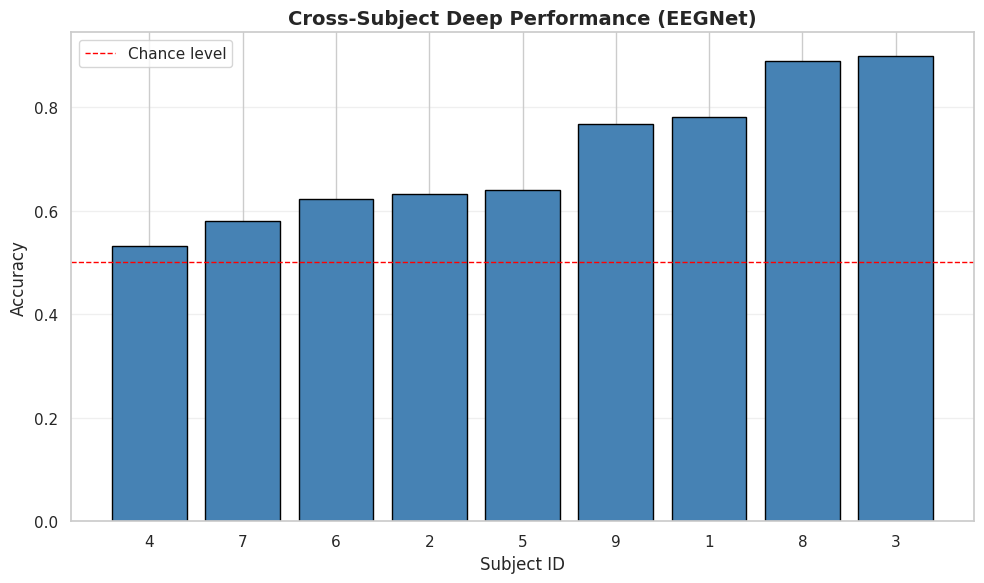

[2026-04-13 19:39:06] Saved plot: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_deep_eegnet/performance_distribution_boxplot.png


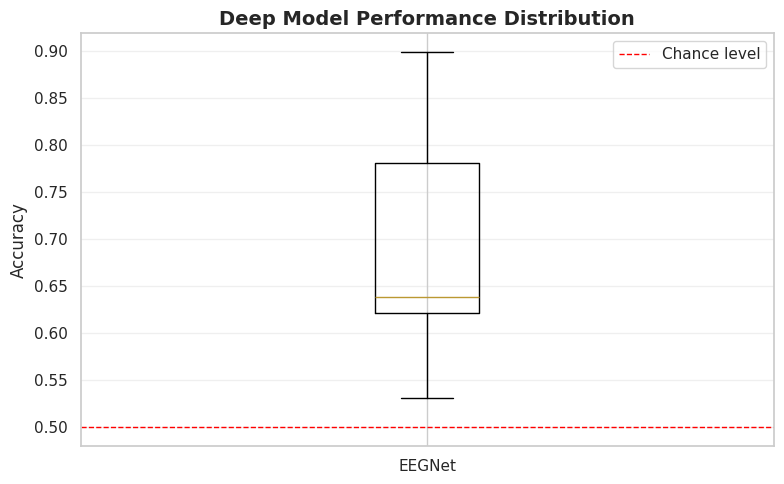

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(
    per_subject_scores['subject'].astype(str),
    per_subject_scores['score'],
    color='steelblue',
    edgecolor='black'
)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Subject Deep Performance (EEGNet)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('per_subject_accuracy_bar.png')
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot([per_subject_scores['score'].values], labels=['EEGNet'])
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.ylabel('Accuracy', fontsize=12)
plt.title('Deep Model Performance Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('performance_distribution_boxplot.png')
plt.show()

# 5.3. Save Artifacts

In [14]:
save_table(results, 'results.csv')
save_table(per_subject_scores, 'per_subject_scores.csv')
save_table(summary_metrics, 'summary_metrics.csv')

summary_payload = summary_metrics.iloc[0].to_dict()
summary_payload['bottom_3_subjects'] = [int(s) for s in bottom_subjects['subject'].tolist()]
summary_payload['median_score'] = median_score
summary_payload['subjects_below_median'] = below_median
save_json(summary_payload, 'summary_metrics.json')

print('All required artifacts were saved successfully.')

[2026-04-13 19:39:06] Saved table: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_deep_eegnet/results.csv
[2026-04-13 19:39:06] Saved table: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_deep_eegnet/per_subject_scores.csv
[2026-04-13 19:39:06] Saved table: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_deep_eegnet/summary_metrics.csv
[2026-04-13 19:39:06] Saved JSON: /home/vegorov/Repos/bci-inefficiency-analysis/artifacts/03_deep_eegnet/summary_metrics.json
[2026-04-13 19:39:06] All required artifacts were saved successfully.
